# News Collector Agent

This notebook collects news headlines and published dates from:
- The Hindu (https://www.thehindu.com/latest-news/)
- Times of India (https://timesofindia.indiatimes.com/)
- BBC (https://www.bbc.com/)

**Topics**: Science, Technology, Sports, World, Space, India News
**Search Limit**: 5 searches total


In [1]:
## utilities
from dotenv import load_dotenv
from typing import Annotated, List, Dict
from pydantic import BaseModel
from IPython.display import Image, display
from typing import TypedDict
from pathlib import Path
from IPython.display import Markdown
import re
from datetime import datetime
import json
## langgraph and langchain
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_openai import ChatOpenAI
from langchain_core.tools import Tool
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_community.utilities import GoogleSerperAPIWrapper

# Additional model providers
try:
    from langchain_google_genai import ChatGoogleGenerativeAI
except ImportError:
    ChatGoogleGenerativeAI = None

try:
    from langchain_anthropic import ChatAnthropic
except ImportError:
    ChatAnthropic = None

try:
    from langchain_ollama import ChatOllama
except ImportError:
    ChatOllama = None


In [3]:
load_dotenv(override=True)

# Model Selection
MODEL_PROVIDER = "openai"  # Default to OpenAI

# Model-specific configurations
MODEL_CONFIGS = {
    "openai": {
        "model": "gpt-4o-mini",
        "base_url": None,
        "api_key_env": "OPENAI_API_KEY"
    },
    "gemini": {
        "model": "gemini-2.5-flash",
        "base_url": "https://generativelanguage.googleapis.com/v1beta/openai/",
        "api_key_env": "GOOGLE_API_KEY"
    },
    "ollama": {
        "model": "llama3-groq-tool-use",
        "base_url": "http://localhost:11434/v1",
        "api_key_env": "OLLAMA_API_KEY"
    },
    "mistral": {
        "model": "mistral-small-latest",
        "base_url": "https://api.mistral.ai/v1",
        "api_key_env": "MISTRAL_API_KEY"
    }
}

_commented = """
def get_llm(provider: str = MODEL_PROVIDER):
   
    import os
    
    if provider not in MODEL_CONFIGS:
        raise ValueError(f"Unknown provider: {provider}")
    
    config = MODEL_CONFIGS[provider]
    api_key = os.getenv(config["api_key_env"])
    
    if provider == "openai":
        return ChatOpenAI(
            model=config["model"],
            temperature=0,
            api_key=api_key
        )
    elif provider == "gemini":
        if ChatGoogleGenerativeAI is None:
            raise ImportError("langchain_google_genai not installed")
        return ChatGoogleGenerativeAI(
            model=config["model"],
            temperature=0,
            google_api_key=api_key
        )
    elif provider == "ollama":
        if ChatOllama is None:
            raise ImportError("langchain_ollama not installed")
        return ChatOllama(
            model=config["model"],
            temperature=0,
            base_url=config["base_url"]
        )
    elif provider == "mistral":
        return ChatOpenAI(
            model=config["model"],
            base_url=config["base_url"],
            api_key=api_key,
            temperature=0
        )
    else:
        raise ValueError(f"Unsupported provider: {provider}")
"""

In [4]:
# Function to initialize LLM based on selected provider
def get_llm(provider: str):
    """Initialize and return the appropriate LLM based on provider."""
    if provider not in MODEL_CONFIGS:
        raise ValueError(f"Unsupported model provider: {provider}. Choose from: {list(MODEL_CONFIGS.keys())}")
    
    config = MODEL_CONFIGS[provider]
    model_name = config["model"]
    base_url = config.get("base_url")
    api_key_env = config.get("api_key_env")

    api_key = None
    if api_key_env:
        import os
        api_key = os.getenv(api_key_env)
        if not api_key and base_url:  # only warn when non-default endpoint needs a key
            raise ValueError(f"Environment variable {api_key_env} is required for provider '{provider}'.")

    # Initialize ChatOpenAI with optional base_url and api_key overrides
    return ChatOpenAI(
        model=model_name,
        base_url=base_url,
        api_key=api_key,
    )   

In [5]:
### Search Tool Setup
serper = GoogleSerperAPIWrapper()

tool_search = Tool(
    name="search",
    func=serper.run,
    description=(
        "Use this tool to search for news headlines and articles. "
        "Search results should include the headline, source, and published date. "
        "IMPORTANT: You have a maximum of 5 searches total. Use them efficiently."
    )
)

tools = [tool_search]


In [6]:
### State Definition

class NewsCollectorState(TypedDict):
    """State for News Collector Agent."""
    messages: Annotated[list, add_messages]
    news_items: List[Dict[str, str]]  # List of {headline, date, source}
    search_count: int  # Track number of searches
    sources_processed: List[str]  # Track which sources have been processed


In [ ]:
### News Sources Configuration

NEWS_SOURCES = [
    {
        "name": "The Hindu",
        "url": "https://www.thehindu.com/latest-news/"
    },
    {
        "name": "Times of India",
        "url": "https://timesofindia.indiatimes.com/"
    },
    {
        "name": "BBC",
        "url": "https://www.bbc.com/"
    }
]

TOPICS = ["science", "technology", "sports", "world", "space", "India news"]
MAX_SEARCHES = 2


In [ ]:
### LangGraph Nodes

def collect_news_node(state: NewsCollectorState) -> NewsCollectorState:
    """Node to collect news headlines and dates from specified sources."""
    
    today = datetime.now().strftime("%B %d, %Y")
    
    # Build search queries for each source with topic filters
    topics_str = ", ".join(TOPICS)
    
    search_prompt = f"""Search for recent news headlines from the following sources for topics: {topics_str}.

Target Sources:
1. The Hindu: https://www.thehindu.com/latest-news/

REQUIREMENTS:
1. Search for news from these specific sources
2. Focus ONLY on these topics: {topics_str}
3. Extract the HEADLINE and PUBLISHED DATE for each news item
4. Format the date clearly (e.g., "January 8, 2026")
5. You have a maximum of {MAX_SEARCHES} searches total. Use them efficiently by combining sources or topics when possible.

Output format for each news item:
- Headline: [exact headline]
- Date: [published date]
- Source: [source name: The Hindu, Times of India, or BBC]

Search strategically to get news from all three sources while staying within the search limit."""
    
    llm = get_llm(MODEL_PROVIDER)
    llm_with_tools = llm.bind_tools(tools)
    
    messages = state["messages"].copy()
    messages.append(
        SystemMessage(content="You are a news collector. Extract headlines and dates from search results. Be precise and efficient.")
    )
    messages.append(HumanMessage(content=search_prompt))
    
    search_count = state.get("search_count", 0)
    news_items = state.get("news_items", [])
    
    # Collect news with search tool (max 5 searches)
    while search_count < MAX_SEARCHES:
        response = llm_with_tools.invoke(messages)
        messages.append(response)
        print(f"Response1: {response}")
        if hasattr(response, 'tool_calls') and response.tool_calls:
            for tool_call in response.tool_calls:
                if tool_call['name'] == 'search':
                    search_query = tool_call['args'].get('__arg1', '')
                    result = serper.run(search_query)
                    search_count += 1
                    print(f"Result: {result}")
                    
                    messages.append(ToolMessage(
                        content=str(result),
                        tool_call_id=tool_call['id']
                    ))
        else:
            # No more tool calls, extract news from final response
            break
    
    # Extract news items from the final response
    if messages:
        final_response = messages[-1]
        print(f"FinalResponse: {final_response}")
        if hasattr(final_response, 'content'):
            news_content = final_response.content
            
            # Parse news items from response
            parsed_items = parse_news_from_response(news_content)
            news_items.extend(parsed_items)
    
    state["search_count"] = search_count
    state["news_items"] = news_items
    state["messages"] = messages
    
    return state


def parse_news_from_response(content: str) -> List[Dict[str, str]]:
    """Parse news headlines, dates, and sources from LLM response."""
    news_items = []
    
    # Pattern to match news items
    # Look for patterns like "Headline: ...", "Date: ...", "Source: ..."
    lines = content.split("\n")
    
    current_item = {}
    
    for line in lines:
        line = line.strip()
        if not line:
            if current_item:
                if "headline" in current_item and "date" in current_item:
                    news_items.append(current_item)
                current_item = {}
            continue
        
        # Check for headline
        if "headline" in line.lower() or "title" in line.lower():
            headline_match = re.search(r'[Hh]eadline[\s:]+(.+)', line, re.IGNORECASE)
            if not headline_match:
                headline_match = re.search(r'[Tt]itle[\s:]+(.+)', line, re.IGNORECASE)
            if headline_match:
                current_item["headline"] = headline_match.group(1).strip()
        
        # Check for date
        elif "date" in line.lower():
            date_match = re.search(r'[Dd]ate[\s:]+(.+)', line, re.IGNORECASE)
            if date_match:
                current_item["date"] = date_match.group(1).strip()
        
        # Check for source
        elif "source" in line.lower():
            source_match = re.search(r'[Ss]ource[\s:]+(.+)', line, re.IGNORECASE)
            if source_match:
                current_item["source"] = source_match.group(1).strip()
        
        # If line starts with a number or bullet, it might be a headline
        elif re.match(r'^[\d\-\*]+\.?\s+', line) and len(line) > 20:
            if "headline" not in current_item:
                # Extract headline (remove numbering)
                headline = re.sub(r'^[\d\-\*]+\.?\s+', '', line)
                current_item["headline"] = headline.strip()
    
    # Add last item if exists
    if current_item and "headline" in current_item and "date" in current_item:
        news_items.append(current_item)
    
    # Fallback: if no structured items found, try to extract from markdown or JSON
    if not news_items:
        # Try to find JSON in the response
        json_match = re.search(r'\[\{.*\}\]', content, re.DOTALL)
        if json_match:
            try:
                news_items = json.loads(json_match.group(0))
            except:
                pass
    
    return news_items


def format_output_node(state: NewsCollectorState) -> NewsCollectorState:
    """Node to format the collected news into a final output."""
    
    news_items = state.get("news_items", [])
    
    # Filter news by topics (case-insensitive check)
    filtered_items = []
    topics_lower = [t.lower() for t in TOPICS]
    
    for item in news_items:
        headline = item.get("headline", "").lower()
        # Check if headline contains any of the topics
        if any(topic in headline for topic in topics_lower):
            filtered_items.append(item)
    
    # If no items match, include all items (LLM should have filtered)
    if not filtered_items:
        filtered_items = news_items
    
    # Format output
    output_lines = [
        "# 📰 News Headlines Collection\n",
        f"**Date Collected**: {datetime.now().strftime('%B %d, %Y %I:%M %p')}\n",
        f"**Total Items**: {len(filtered_items)}\n",
        f"**Searches Used**: {state.get('search_count', 0)}/{MAX_SEARCHES}\n",
        "\n---\n\n"
    ]
    
    for i, item in enumerate(filtered_items, 1):
        headline = item.get("headline", "N/A")
        date = item.get("date", "N/A")
        source = item.get("source", "Unknown")
        
        output_lines.append(f"## {i}. {headline}\n")
        output_lines.append(f"- **Date**: {date}\n")
        output_lines.append(f"- **Source**: {source}\n\n")
    
    output_text = "".join(output_lines)
    
    # Add formatted output to messages
    messages = state["messages"].copy()
    messages.append(AIMessage(content=output_text))
    state["messages"] = messages
    
    return state


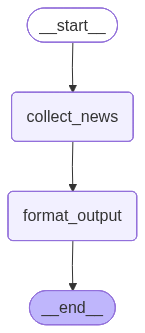

In [9]:
### Create LangGraph

def create_news_collector_graph():
    """Create the news collector graph."""
    
    workflow = StateGraph(NewsCollectorState)
    
    # Add nodes
    workflow.add_node("collect_news", collect_news_node)
    workflow.add_node("format_output", format_output_node)
    
    # Define workflow: start -> collect_news -> format_output -> end
    workflow.add_edge(START, "collect_news")
    workflow.add_edge("collect_news", "format_output")
    workflow.add_edge("format_output", END)
    
    return workflow.compile()


# Create the graph
news_collector_graph = create_news_collector_graph()

# Display the graph
display(Image(news_collector_graph.get_graph().draw_mermaid_png()))


In [10]:
### Run the News Collector

def collect_news():
    """Execute the news collection workflow."""
    
    initial_state = {
        "messages": [],
        "news_items": [],
        "search_count": 0,
        "sources_processed": []
    }
    
    # Invoke the graph
    final_state = news_collector_graph.invoke(initial_state)
    
    # Get the final output message
    final_messages = final_state.get("messages", [])
    
    if final_messages:
        last_message = final_messages[-1]
        if hasattr(last_message, 'content'):
            return last_message.content
    
    return "No news collected."


# Run the collector
result = collect_news()
display(Markdown(result))


# 📰 News Headlines Collection
**Date Collected**: January 08, 2026 09:36 AM
**Total Items**: 0
**Searches Used**: 6/5

---



In [11]:
### Optional: Export to JSON

def export_news_to_json(state: NewsCollectorState, filename: str = "collected_news.json"):
    """Export collected news to JSON file."""
    news_items = state.get("news_items", [])
    
    export_data = {
        "collection_date": datetime.now().isoformat(),
        "total_items": len(news_items),
        "searches_used": state.get("search_count", 0),
        "news_items": news_items
    }
    
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(export_data, f, indent=2, ensure_ascii=False)
    
    print(f"News exported to {filename}")
    return export_data


# Example usage
# initial_state = {"messages": [], "news_items": [], "search_count": 0, "sources_processed": []}
# final_state = news_collector_graph.invoke(initial_state)
# export_news_to_json(final_state)
